In [1]:
import ternary
import matplotlib.pyplot as plt
import mpltern
import matplotlib as mpl
import seaborn as sns

In [12]:
from utils.paths import SAMPLING_DIR, RAW_DIR,PREDICTIONS_DIR,PLOTS_DIR

In [4]:
import pandas as pd
import numpy as np
import sqlite3
import pickle

Data distribution from the generalized 

In [29]:
Data_AFLOW = pd.read_pickle(path_root+"/Data_Extraction/DataFrame_composition_AFLOW.pkl")


In [30]:
Data_AFLOW_simple = Data_AFLOW[["Cu","Ni","Al"]]

In [31]:
Data_AFLOW_plot = Data_AFLOW.melt(
    var_name="Element",   # former column names
    value_name="Value"    # data values
)

Data_AFLOW_plot["Value"] = pd.to_numeric(Data_AFLOW_plot["Value"], errors="coerce")
Data_AFLOW_plot = Data_AFLOW_plot[Data_AFLOW_plot["Value"] != 0]

In [32]:
max_15 = Data_AFLOW_plot['Element'].value_counts().head(15).index
Data_AFLOW_plot_2 = Data_AFLOW_plot[Data_AFLOW_plot["Element"].isin(max_15)]

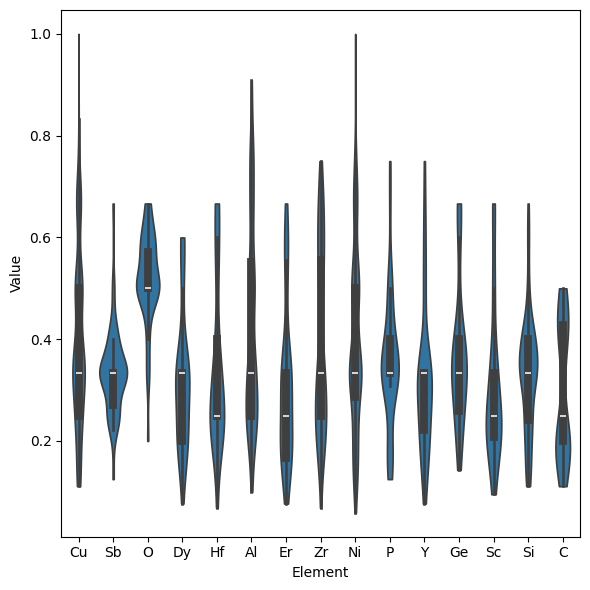

In [60]:
plt.figure(figsize=(6,6))
sns.violinplot(
    data=Data_AFLOW_plot_2,
    y="Value",   # categorical on Y
    x="Element",     # numeric on X
    cut=0
)
plt.tight_layout()
plt.show()

## Ternnary plot

Ternary plot using EMA
1. Relaxation time calculation
2. E1 (1550)
3. E2 (1550)

In [5]:
db = DatabaseManager(path_root+"/Data_Extraction/Databases/Synthetic_data_EMA.db")
df_EMA_data = db.table_dataframe(table_name='Optical_properties')
db.close()

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/Data_Extraction/Databases/Synthetic_data_EMA.db
Database connection closed


In [6]:
df_EMA_data[["Cu","Ni","Al"]] =df_EMA_data[["Cu","Ni","Al"]]*100
wave_1550 = df_EMA_data[df_EMA_data["wavelength_nm"] == 1552]
wave_1550 = wave_1550.drop(columns='wavelength_nm')

In [13]:
## Scales
vmin = min(wave_1550['e2'].min(), e2_predict_ER_model['e2'].min())
vmax = max(wave_1550['e2'].max(), e2_predict_ER_model['e2'].max())

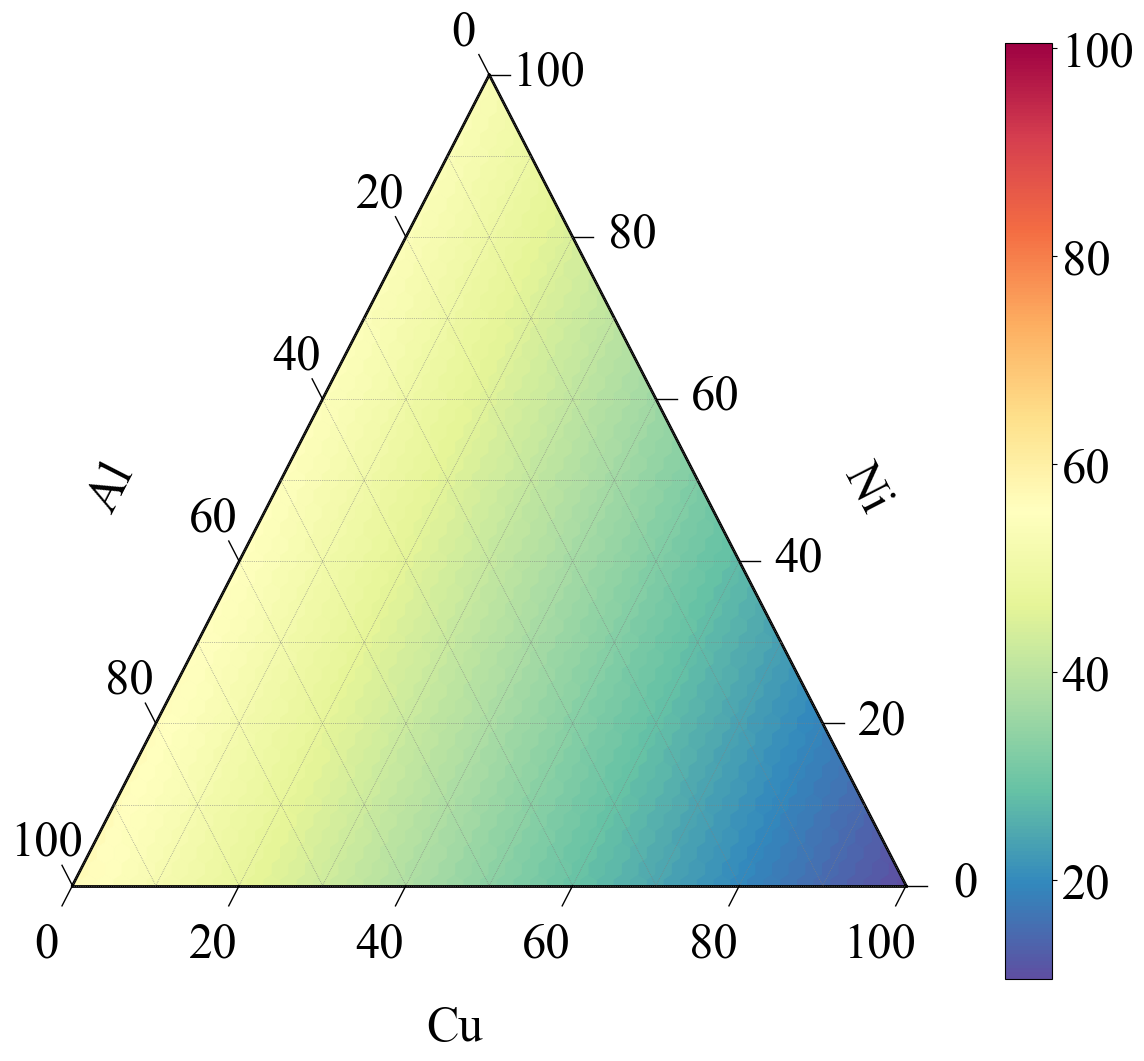

In [17]:
df = wave_1550.copy()
df = df.dropna(subset=["Cu","Ni","Al","e2"]).copy()

scale = 50
pct_per_unit = 100 / scale   # = 2 → each tick unit equals 2%

# Convert % comps to lattice coords that sum to scale
coords = (df[["Cu","Ni","Al"]] / 100 * scale).round().astype(int)

# Fix rounding drift so Cu+Ni+Al == scale
drift = scale - coords.sum(axis=1)
maxcol = df[["Cu","Ni","Al"]].values.argmax(axis=1)
for i in range(len(coords)):
    coords.iat[i, maxcol[i]] += drift.iat[i]

df[["Cu","Ni","Al"]] = coords

g = df.groupby(["Cu","Ni","Al"])["e2"].mean()
data = g.to_dict()

fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(12, 10)

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

tax.heatmap(data, style="hexagonal", cmap="Spectral_r", colorbar=True, vmin=vmin,vmax=vmax)

cax = fig.axes[-1]
cax.tick_params(labelsize=35)

tax.boundary(linewidth=2.0)
tax.gridlines(color="gray", multiple=5)

tax.left_axis_label("Al", fontsize=35, offset=0.20)
tax.right_axis_label("Ni", fontsize=35, offset=0.20)
tax.bottom_axis_label("Cu", fontsize=35, offset=0.15)

tax.ticks(axis='lbr', multiple=10, offset=0.025, linewidth=1, fontsize=35)

# -------------------------------------------------
# Convert tick labels from 0–50 → 0–100
# -------------------------------------------------
ax = tax.get_axes()

for txt in ax.texts:
    label = txt.get_text().strip()

    try:
        value = float(label)
        new_label = value * pct_per_unit   # multiply by 2
        txt.set_text(str(int(new_label)))
    except:
        pass
# -------------------------------------------------

tax.clear_matplotlib_ticks()

ax = tax.get_axes()
ax.set_frame_on(False) 
ax.axis("off")         

plt.tight_layout()
#plt.show()
plt.savefig(path_root+"/plots/EMA_plot.svg", format="svg", bbox_inches="tight")

In [8]:
e2_predict_ER_model = pd.read_pickle(PREDICTIONS_DIR / "ANN_Predictions/ANN_e2_calculated.pkl")

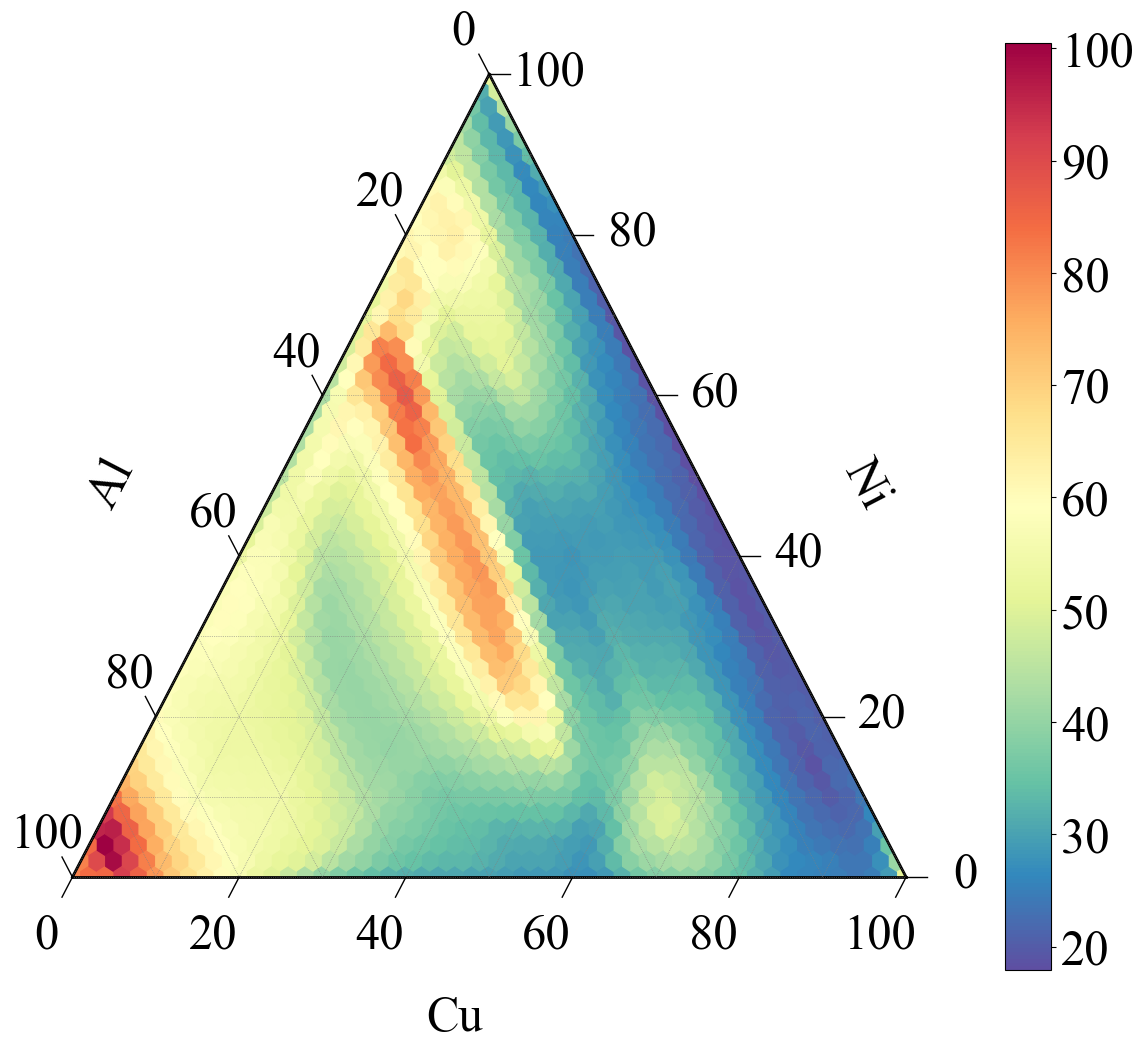

In [13]:
df = e2_predict_ER_model.copy()
df = df.dropna(subset=["Cu","Ni","Al","e2"]).copy()

scale = 50          
label_factor = 2    

# Convert comps to lattice coords that sum to scale
coords = (df[["Cu","Ni","Al"]] * scale).round().astype(int)

# Fix rounding drift so Cu+Ni+Al == scale
drift = scale - coords.sum(axis=1)
maxcol = df[["Cu","Ni","Al"]].values.argmax(axis=1)
for i in range(len(coords)):
    coords.iat[i, maxcol[i]] += drift.iat[i]

df[["Cu","Ni","Al"]] = coords

# Average e2 if multiple points map to same lattice cell
g = df.groupby(["Cu","Ni","Al"])["e2"].mean()
data = g.to_dict()

fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(12, 10)

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

tax.heatmap(data, style="hexagonal", cmap="Spectral_r", colorbar=True,vmin=None,vmax=None)

cax = fig.axes[-1]
cax.tick_params(labelsize=35)

tax.boundary(linewidth=2.0)
tax.gridlines(color="gray", multiple=5)
tax.left_axis_label("Al", fontsize=35, offset=0.20)
tax.right_axis_label("Ni", fontsize=35, offset=0.20)
tax.bottom_axis_label("Cu", fontsize=35, offset=0.15)

tax.ticks(axis='lbr', multiple=10, offset=0.025, linewidth=1, fontsize=35)

# ---------- ONLY CHANGE: relabel tick text (0..50 -> 0..100) ----------
ax = tax.get_axes()
for txt in ax.texts:
    s = txt.get_text().strip()
    # tick labels are usually numbers; convert safely
    try:
        v = float(s)
        # Replace tick label with scaled value
        # Keep integers clean (no .0)
        new = v * label_factor
        txt.set_text(str(int(new)) if abs(new - round(new)) < 1e-9 else str(new))
    except ValueError:
        pass
# ----------------------------------------------------------------------

tax.clear_matplotlib_ticks()
ax = tax.get_axes()
ax.set_frame_on(False) 
ax.axis("off")   

plt.tight_layout()
#plt.show()
plt.savefig(PLOTS_DIR/"ANN_plot.svg", format="svg", bbox_inches="tight")

Plot GP-Experimental data (First round - Transfer Learning)

Composition spliting

In [103]:
train_comp = pd.read_csv(path_root+"/Data_Extraction/Results/GP-Experiments/train_exp_comp")
test_comp = pd.read_csv(path_root+"/Data_Extraction/Results/GP-Experiments/test_exp_comp")

train_comp = np.asarray(train_comp, dtype=float)*100
test_comp = np.asarray(test_comp, dtype=float)*100

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


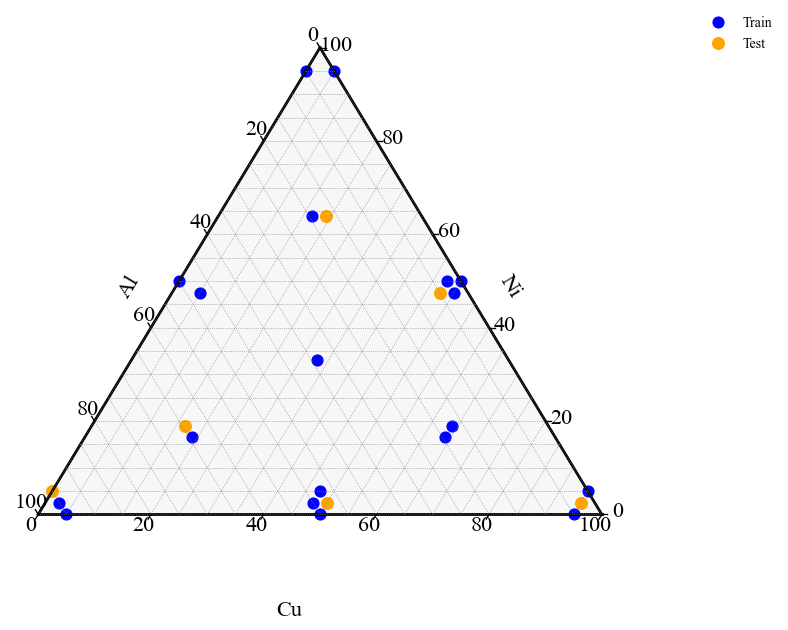

In [104]:
scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp, scale)
pts_B = to_ternary_points(test_comp, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.2)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)
plt.show()
#plt.savefig(path_root+"/plots/3_comp_plot.svg", format="svg", bbox_inches="tight")

In [105]:
e2_predict_GP_exp =  np.load(path_root+"/Data_Extraction/Results/GP-Experiments/e2_predicted_GP.npy")

In [ ]:
df = wave_1550.copy()
df = df.dropna(subset=["Cu","Ni","Al","e2"])
df = df.drop(columns=['e1','e2','ID'])
df['e2'] = e2_predict_GP_exp

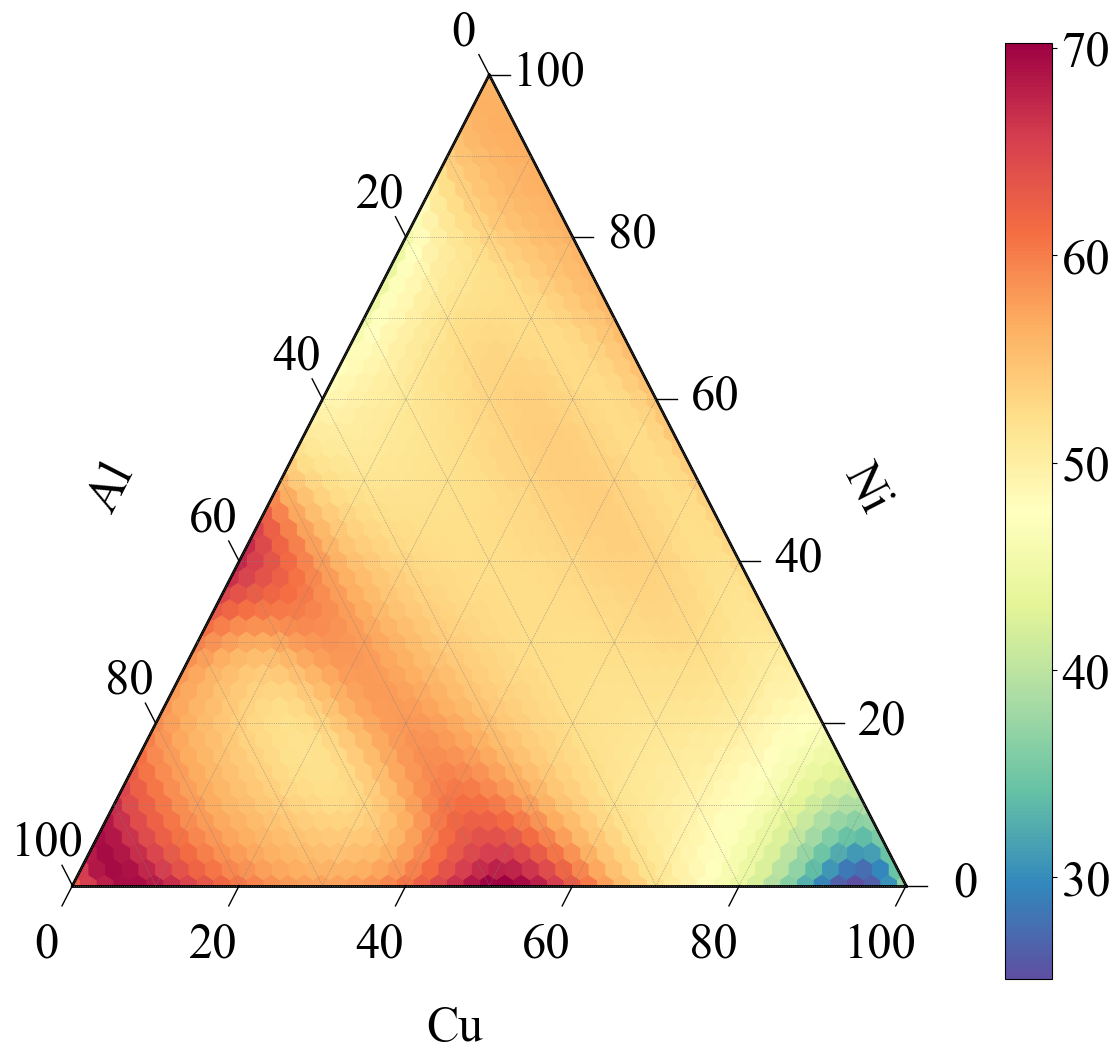

In [120]:
df = wave_1550.copy()
df = df.dropna(subset=["Cu","Ni","Al","e2"])
df = df.drop(columns=['e1','e2','ID'])
df['e2'] = e2_predict_GP_exp

scale = 50          
label_factor = 2    

# Convert comps to lattice coords that sum to scale
coords = (df[["Cu","Ni","Al"]]/100 * scale).round().astype(int)

# Fix rounding drift so Cu+Ni+Al == scale
drift = scale - coords.sum(axis=1)
maxcol = df[["Cu","Ni","Al"]].values.argmax(axis=1)
for i in range(len(coords)):
    coords.iat[i, maxcol[i]] += drift.iat[i]

df[["Cu","Ni","Al"]] = coords

# Average e2 if multiple points map to same lattice cell
g = df.groupby(["Cu","Ni","Al"])["e2"].mean()
data = g.to_dict()

fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(12, 10)

mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

tax.heatmap(data, style="hexagonal", cmap="Spectral_r", colorbar=True)

cax = fig.axes[-1]
cax.tick_params(labelsize=35)

tax.boundary(linewidth=2.0)
tax.gridlines(color="gray", multiple=5)
tax.left_axis_label("Al", fontsize=35, offset=0.20)
tax.right_axis_label("Ni", fontsize=35, offset=0.20)
tax.bottom_axis_label("Cu", fontsize=35, offset=0.15)

tax.ticks(axis='lbr', multiple=10, offset=0.025, linewidth=1, fontsize=35)

# ---------- ONLY CHANGE: relabel tick text (0..50 -> 0..100) ----------
ax = tax.get_axes()
for txt in ax.texts:
    s = txt.get_text().strip()
    # tick labels are usually numbers; convert safely
    try:
        v = float(s)
        # Replace tick label with scaled value
        # Keep integers clean (no .0)
        new = v * label_factor
        txt.set_text(str(int(new)) if abs(new - round(new)) < 1e-9 else str(new))
    except ValueError:
        pass
# ----------------------------------------------------------------------

tax.clear_matplotlib_ticks()
ax = tax.get_axes()
ax.set_frame_on(False) 
ax.axis("off")   

plt.tight_layout()
plt.show()

Ternary Experimental work
1. E1 (1550)
2. E2 (1550)

In [225]:
db = DatabaseManager("/Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Ellipsometry/Python/Python_scripts/Database/Ternary_round1.db")
tables = db.list_tables()
df_optical = db.table_dataframe('Optical_properties')
df_compositions = db.table_dataframe('compositions')
print (tables)
db.close()

df_tern_1_rou = pd.merge(df_optical,df_compositions, on='ID')
df_tern_1_rou[["Cu","Ni","Al"]] = df_tern_1_rou[["Cu","Ni","Al"]]*100
tern_1_1550 = df_tern_1_rou[df_tern_1_rou["wavelength_nm"] == 1552]

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Ellipsometry/Python/Python_scripts/Database/Ternary_round1.db
['compositions', 'Thickness', 'Optical_properties']
Database connection closed


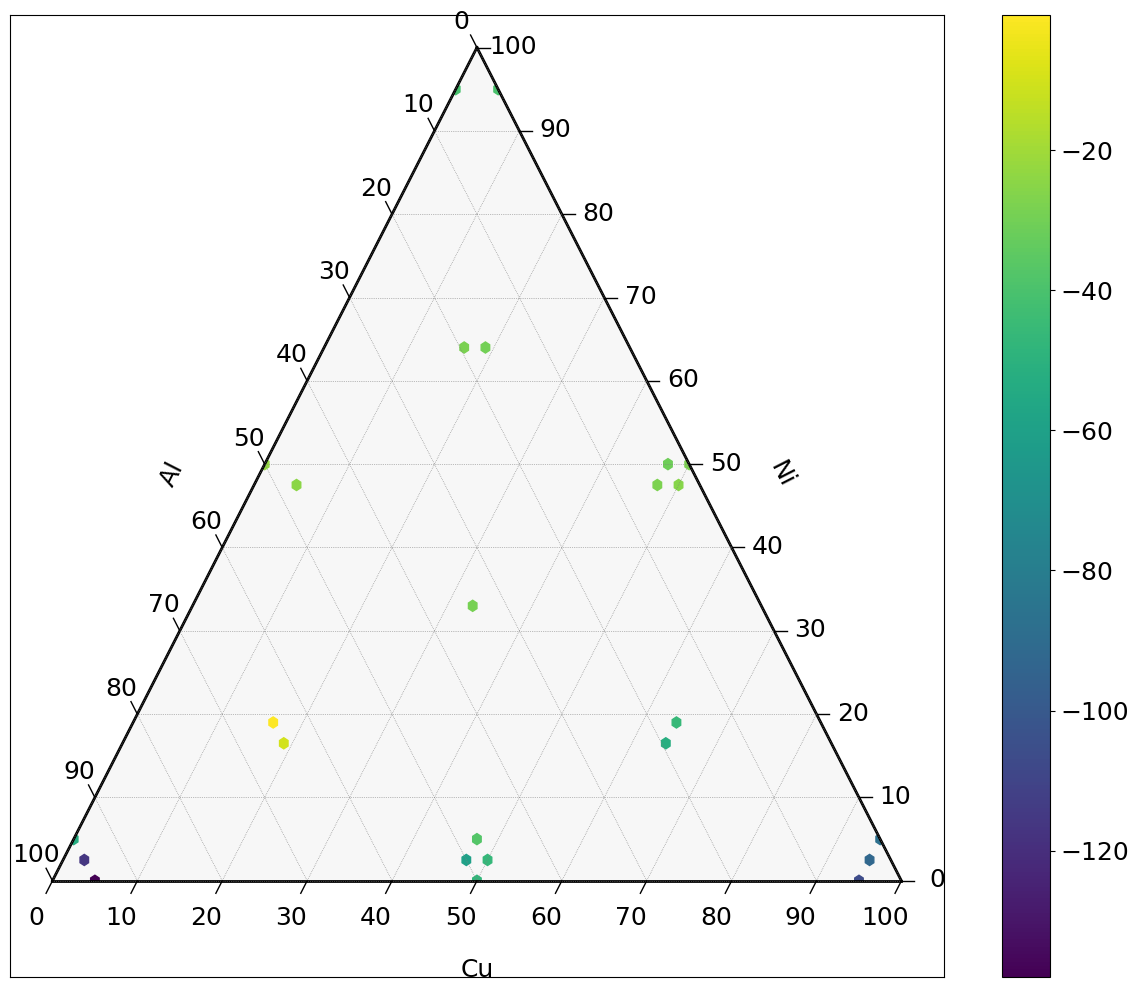

In [226]:
data = tern_1_1550.set_index(["Cu","Ni","Al"])["e1"].to_dict()
# Scale = sum of A+B+C
scale = 100

fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(12, 10)

# Plot heatmap
tax.heatmap(
    data,
    style="hexagonal",
    cmap="viridis",
    colorbar=True
)
cax = fig.axes[-1]
cax.tick_params(labelsize=18)

tax.boundary(linewidth=2.0)
tax.gridlines(color="gray", multiple=10)
#tax.set_title("EMA Relaxation time", fontsize=20)

tax.left_axis_label("Al",fontsize=18,offset =0.12)
tax.right_axis_label("Ni",fontsize=18,offset =0.12)
tax.bottom_axis_label("Cu",fontsize=18,offset =0.0)

tax.ticks(axis='lbr', multiple=10, offset =0.015,linewidth=1,fontsize=18)

tax.clear_matplotlib_ticks()
#fig.patch.set_visible(False)

plt.tight_layout()
#plt.savefig("ternary_heatmap.svg", format="svg")
plt.show()

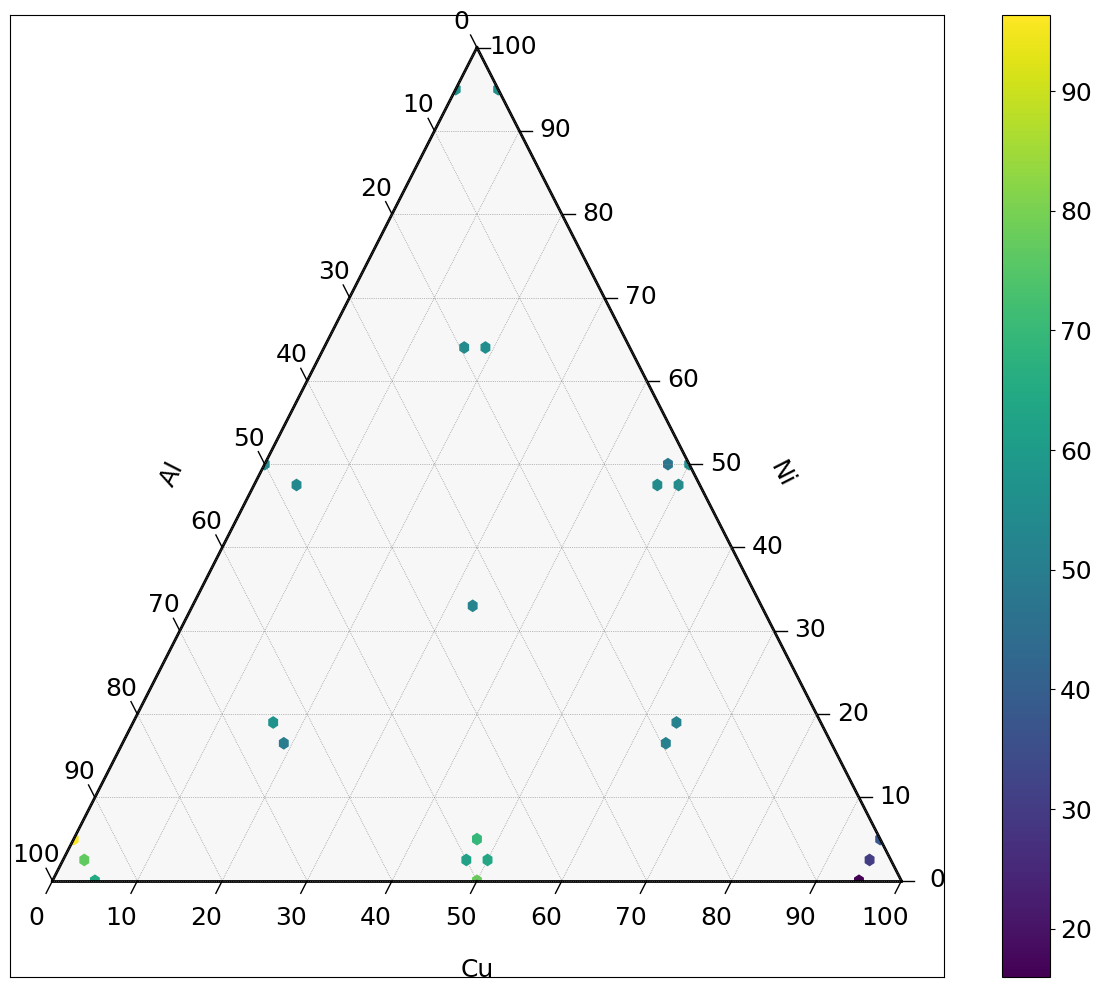

In [227]:
data = tern_1_1550.set_index(["Cu","Ni","Al"])["e2"].to_dict()
# Scale = sum of A+B+C
scale = 100

fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(12, 10)

# Plot heatmap
tax.heatmap(
    data,
    style="hexagonal",
    cmap="viridis",
    colorbar=True
)
cax = fig.axes[-1]
cax.tick_params(labelsize=18)

tax.boundary(linewidth=2.0)
tax.gridlines(color="gray", multiple=10)
#tax.set_title("EMA Relaxation time", fontsize=20)

tax.left_axis_label("Al",fontsize=18,offset =0.12)
tax.right_axis_label("Ni",fontsize=18,offset =0.12)
tax.bottom_axis_label("Cu",fontsize=18,offset =0.0)

tax.ticks(axis='lbr', multiple=10, offset =0.015,linewidth=1,fontsize=18)

tax.clear_matplotlib_ticks()
#fig.patch.set_visible(False)

plt.tight_layout()
#plt.savefig("ternary_heatmap.svg", format="svg")
plt.show()

One composition for the proposal

In [43]:
comp_1 = (47.5, 2.5, 50)
comp_2 = (47.5, 50, 2.5)
comp_3 = (95, 2.5, 2.5)

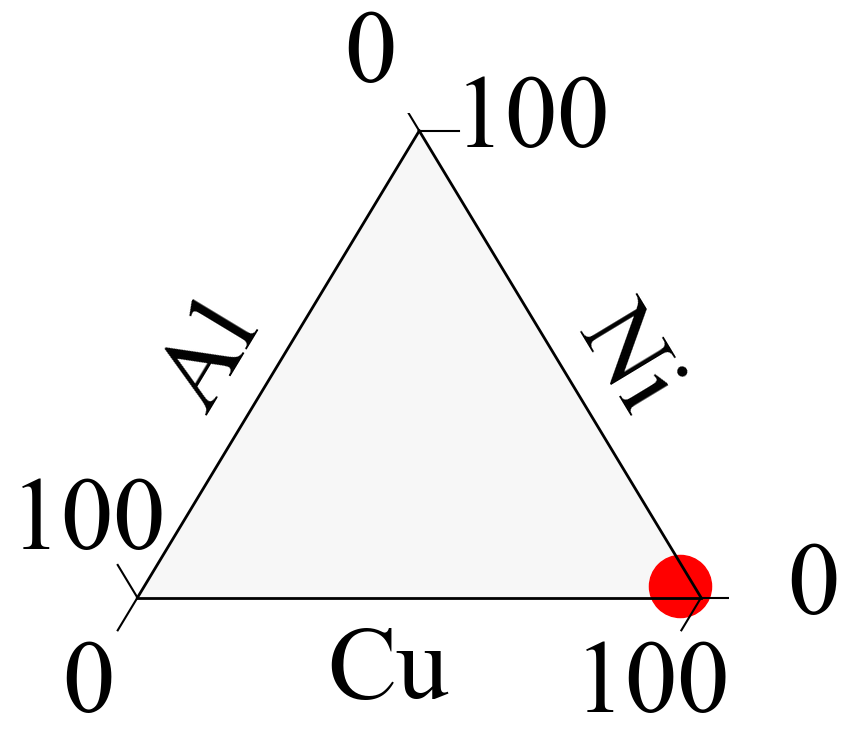

In [74]:
scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

# point composition (Cu, Ni, Al) in %
pt_pct = comp_3

tax.scatter([pt_pct], marker="o", s=2000, color='red')  # single point
tax.boundary(linewidth=2)
tax.ticks(axis='lbr', multiple=100,fontsize=75,offset=0.070)
tax.left_axis_label("Al",fontsize=75,offset=0.1)
tax.right_axis_label("Ni",fontsize=75,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=75,offset=0.2)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
#plt.show()
plt.savefig(path_root+"/plots/3_comp_plot.svg", format="svg", bbox_inches="tight")

In [ ]:
def error_calculation(df1, df2, variables):
    
    # Drop Cu, Ni, Al from df1 only if they exist there
    df1 = df1.drop(columns=['Cu', 'Ni', 'Al'], errors='ignore')
    
    # Merge
    df = df1.merge(df2, on="ID", suffixes=("_df1", "_df2"))

    # Compute error for each variable
    for variable in variables:
        df[f'error_{variable}'] = (
            df[f"{variable}_df1"] - df[f"{variable}_df2"]
        ).abs() / df[f"{variable}_df2"].abs()

    return df

In [ ]:
variables =['e1','e2']
df_error = error_calculation(df_1550,tern_1_1550,variables)

In [2]:
from utils.paths import DATABASE_DIR,RAW_DIR,PREDICTIONS_DIR,EXP_RESULT,PLOTS_DIR
from models_scripts.gp_workflow import ExperimentalGPApproach
from models_scripts.prediction_utils import save_experiment_outputs

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength, predict_composition_space
from data.splitting import DataSplitter
from data.Descriptors import AlloyDescriptorCalculator
from plots.TernaryPlot import plot_ternary_heatmap,plot_train_test_ternary

from evaluation.evaluation import compute_permutation_importance, importance_to_df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

In [3]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_lifetime = load_table(DATABASE_DIR / "Ternary_round1.db", "lifetime")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")
# --- Merge full data ---
df_merged = merge_data(df_optical, df_comp)

# ---- Wavelength selection ----
tern_1550 = filter_by_wavelength(df_merged, 1300).copy()
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[["ID", "resistivity"]])
tern_1550 = merge_data(tern_1550, df_lifetime[["ID", "tau_p","r2"]])

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [4]:
ids = [3,4,5,7,13,18,21,22,23,25,26,27]
tern_1300 = tern_1550[tern_1550["ID"].isin(ids)]
df_lifetime = df_lifetime[df_lifetime["ID"].isin(ids)]
df_comp_limit = df_comp[df_comp["ID"].isin(ids)]

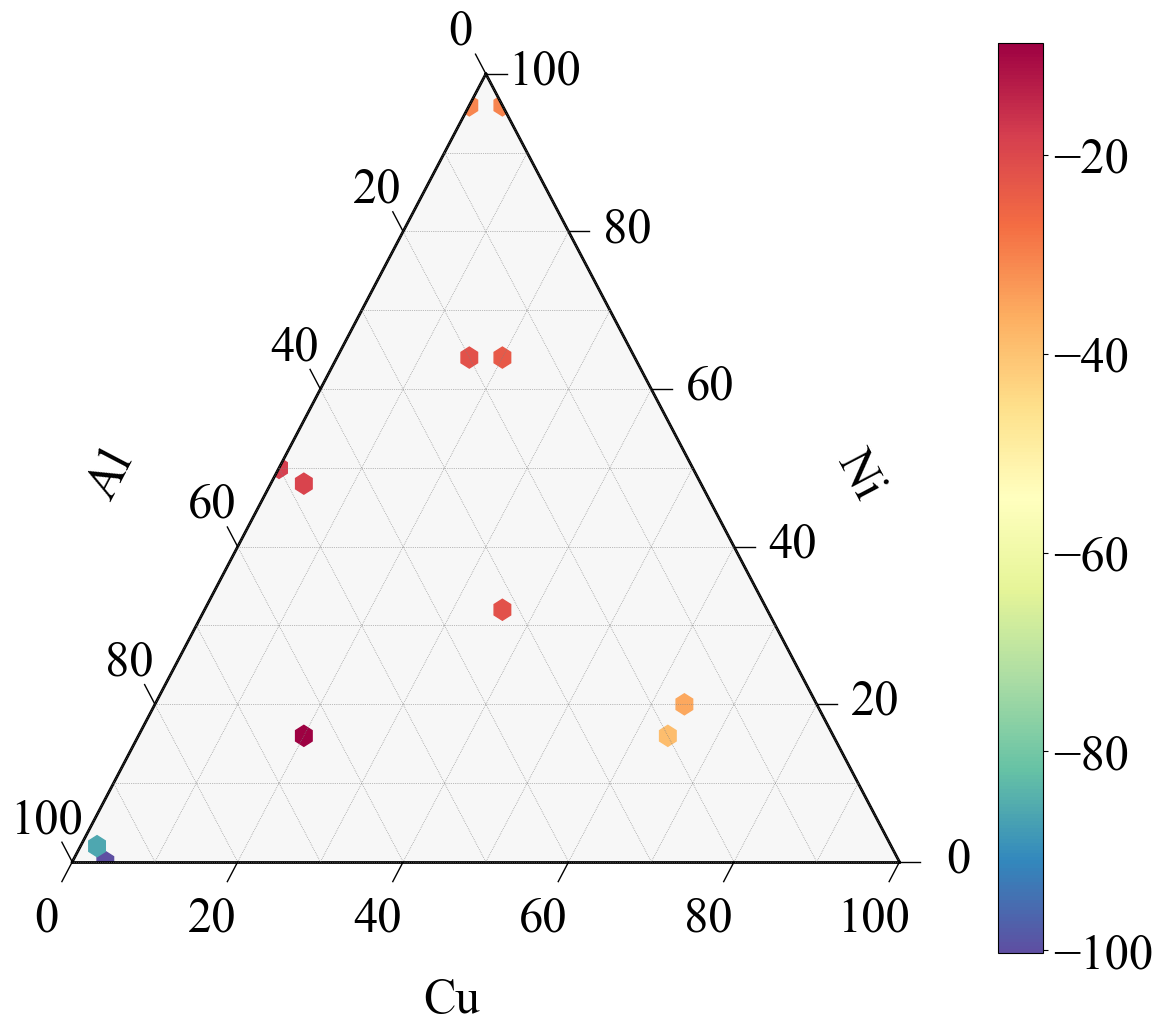

(<Figure size 1200x1000 with 2 Axes>, TernaryAxesSubplot: 390865704)

In [4]:
plot_ternary_heatmap(
    df=tern_1300,
    value_col="e1",
    duplicate_handling="mean",
    save_path=PLOTS_DIR/"Visualization/tern_1300_e1.svg"
)

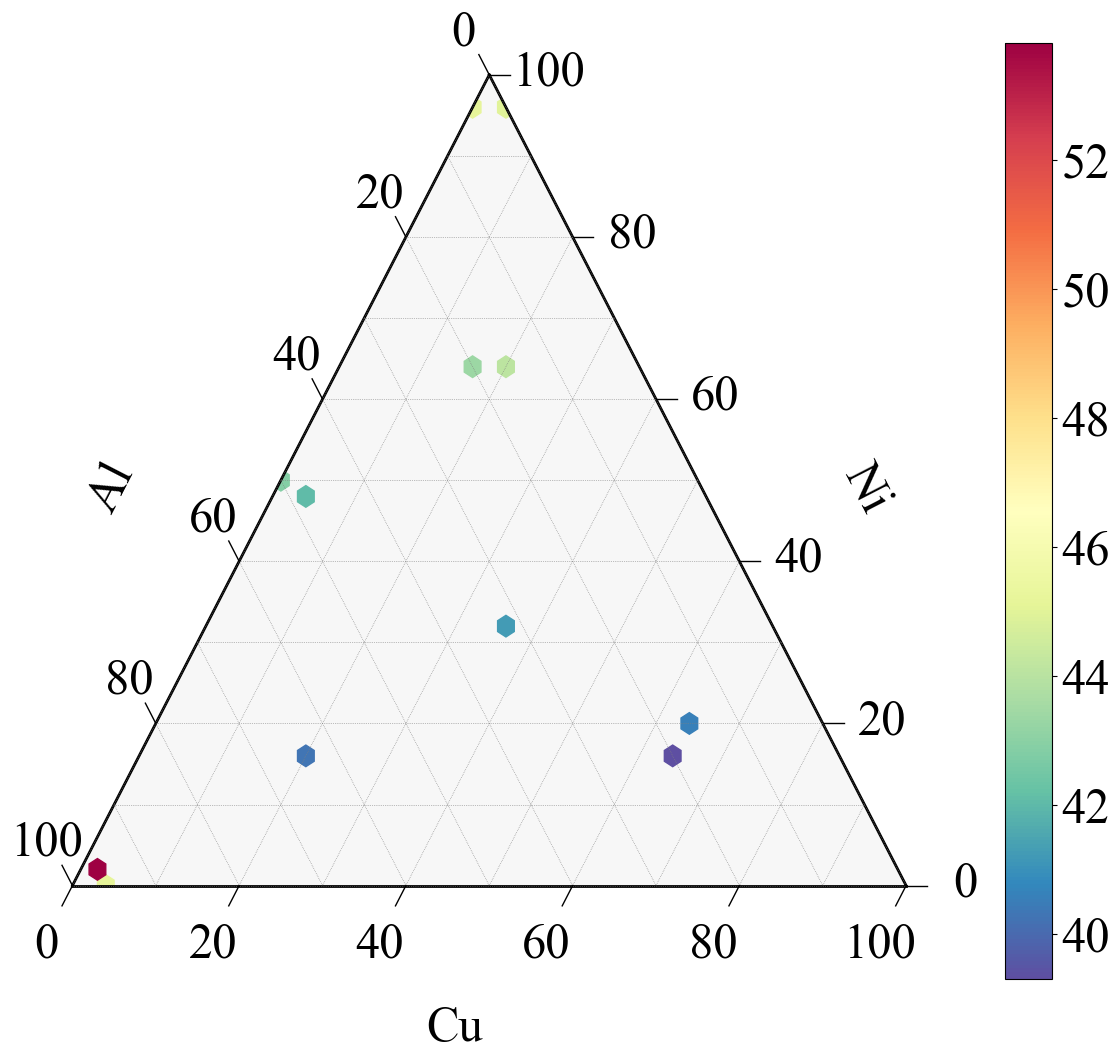

(<Figure size 1200x1000 with 2 Axes>, TernaryAxesSubplot: 391101987)

In [5]:
plot_ternary_heatmap(
    df=tern_1300,
    value_col="e2",
    duplicate_handling="mean",
    save_path=PLOTS_DIR/"Visualization/tern_1300_e2.svg"
)

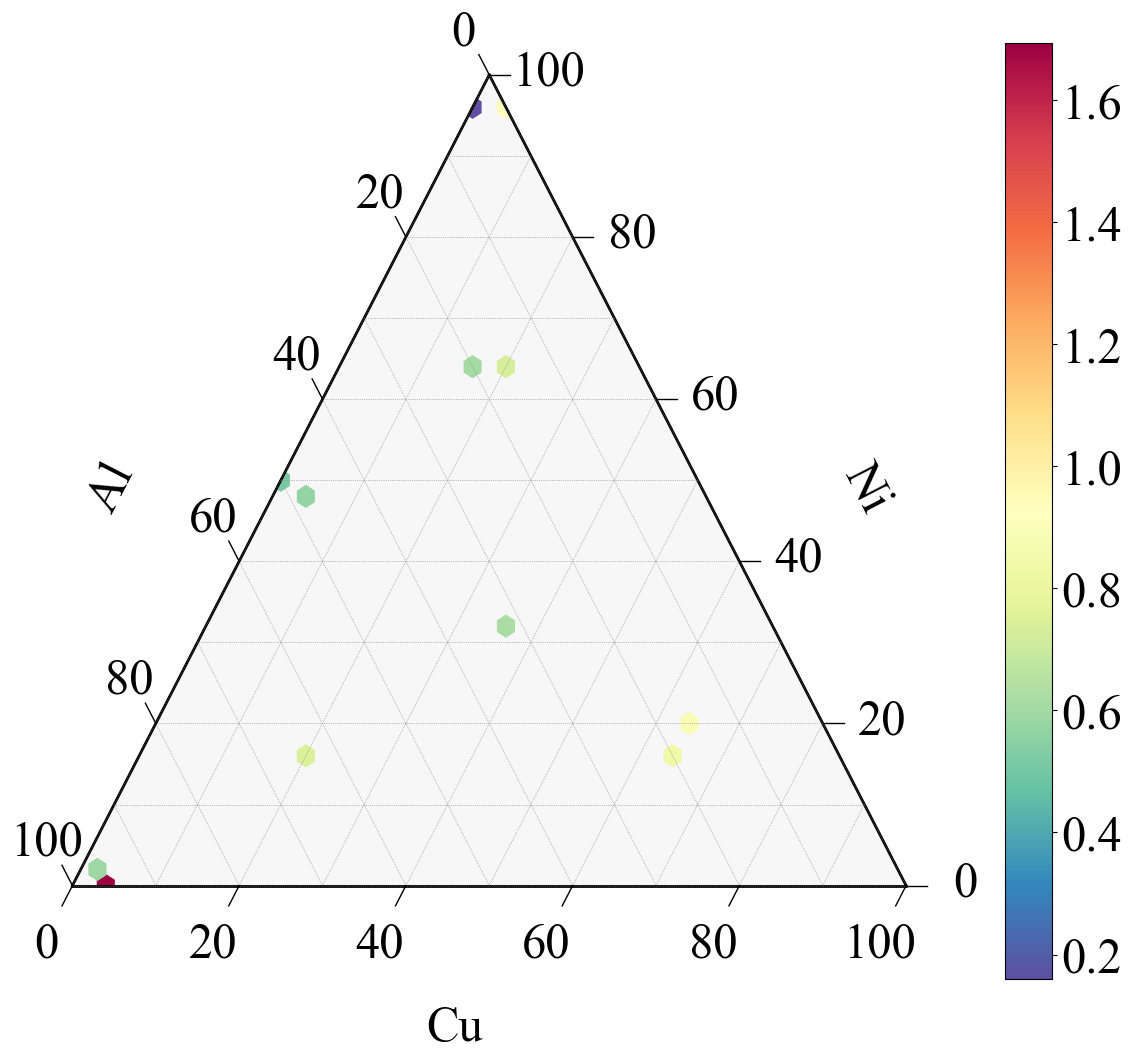

(<Figure size 1200x1000 with 2 Axes>, TernaryAxesSubplot: 392854637)

In [56]:
plot_ternary_heatmap(
    df=tern_1300,
    value_col="tau_p",
    duplicate_handling="mean",
    save_path=PLOTS_DIR/"Visualization/tern_1300_lifetime.svg"
)

ID's positions

In [4]:
import numpy as np
import ternary
import matplotlib.pyplot as plt

def plot_compositions_ternary(
    df,
    composition_cols=("Cu", "Ni", "Al"),
    id_col="ID",
    scale=100,
    figsize=(7, 6),
    point_size=60,
    color="blue",
    label="Compositions",
    annotate=True,
    fontsize_ticks = 14,
    fontsize_labels = 16,
):
    comp_cols = list(composition_cols)

    # Get composition values
    comp = df[comp_cols].to_numpy(dtype=float)

    # Convert to 0–100 if needed
    if comp.max() <= 1.0:
        comp = comp * 100

    # Convert to ternary scale
    pts = comp / 100.0 * scale
    pts = [tuple(p) for p in pts]

    # Plot
    fig, tax = ternary.figure(scale=scale)
    fig.set_size_inches(*figsize)

    tax.scatter(
        pts,
        marker="o",
        s=point_size,
        color=color,
        label=label
    )

    # Add ID labels
    if annotate and id_col in df.columns:
        ids = df[id_col].tolist()

        for (x, y, z), id_val in zip(pts, ids):
            tax.annotate(
                str(id_val),
                (x + 2.5, y + 2.5, z),
                fontsize=12,
                ha="center",
                va="center",
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8
                )
        )

    # Styling
    tax.boundary(linewidth=2)
    tax.gridlines(color="gray", multiple=5)
    tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=fontsize_ticks)

    tax.left_axis_label("Al", fontsize=fontsize_labels, offset=0.1)
    tax.right_axis_label("Ni", fontsize=fontsize_labels, offset=0.1)
    tax.bottom_axis_label("Cu", fontsize=fontsize_labels, offset=0.01)

    tax.clear_matplotlib_ticks()
    tax.get_axes().axis("off")

    tax.legend(
        loc="upper right",
        bbox_to_anchor=(1.25, 1.05),
        frameon=False
    )

    return fig, tax

In [5]:
fig, tax = plot_compositions_ternary(
    df=tern_1300,
    composition_cols=("Cu", "Ni", "Al"),
    id_col="ID",
    figsize=(111, 110),
    point_size=200,
    color="blue",
    annotate=False,
    fontsize_ticks = 120,
    fontsize_labels = 122
)

plt.savefig(PLOTS_DIR/"Visualization/composition.svg", format="svg")

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


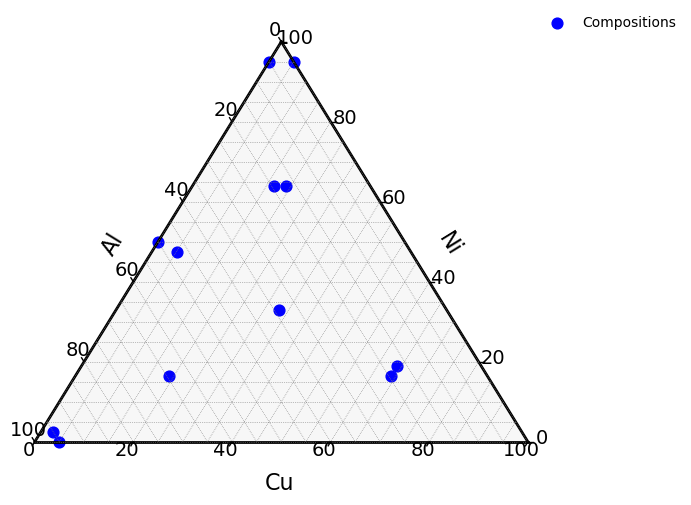

In [5]:
fig, tax = plot_compositions_ternary(
    df=tern_1300,
    composition_cols=("Cu", "Ni", "Al"),
    id_col="ID",
    color="blue",
    annotate=False,
)

plt.show()

In [5]:
split_dict = {}
split_dict['X_train'] = tern_1300[['Cu','Ni','Al']]
split_dict['X_test'] = tern_1550[~tern_1550["ID"].isin(ids)]

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)
/var/folders/kk/7h_k8hgd46ld6cx6qw3lkcpc0000gn/T/ipykernel_90451/3307356397.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


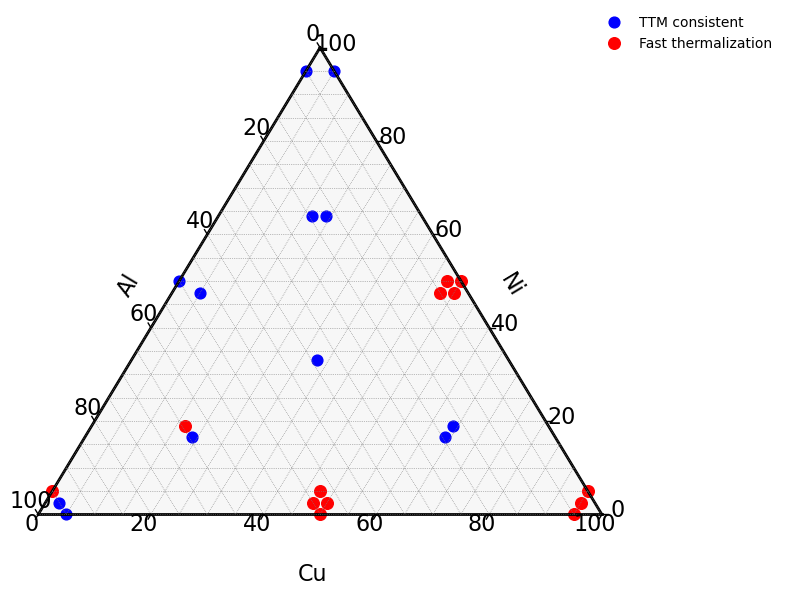

In [6]:
fig, tax = plot_train_test_ternary(
    split_dict,
    train_color="blue",
    test_color="red",
    train_label="TTM consistent",
    test_label="Fast thermalization",
    )
fig.show()

Comparison e1 and e2, lifetime

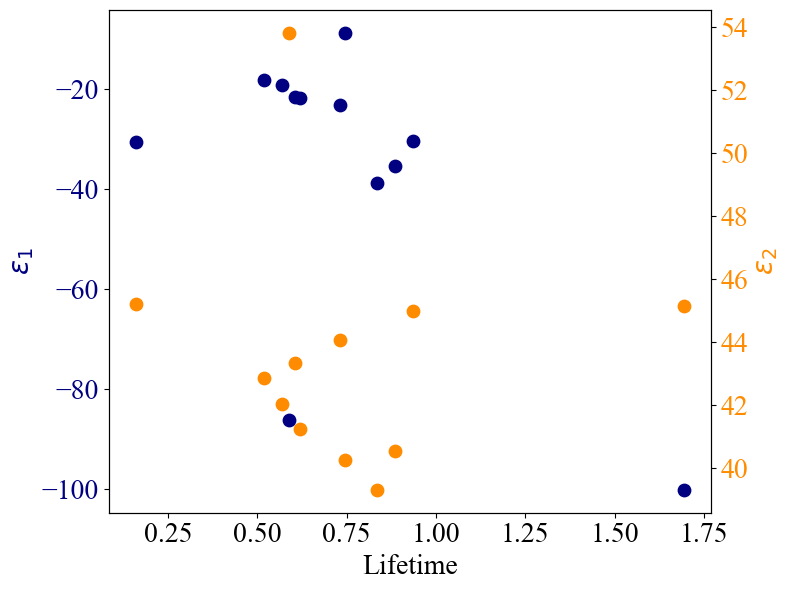

In [7]:

fig,ax1 = plt.subplots(figsize=(8, 6))

## First y-axis
ax1.set_xlabel('Lifetime',fontsize=20)
ax1.set_ylabel(r'$\varepsilon_1$', color='navy',fontsize=20)
ax1.scatter(tern_1300['tau_p'],tern_1300['e1'], color='navy',label='ε1', s=80)
ax1.tick_params(axis='y',labelcolor='navy',labelsize=20)
ax1.tick_params(axis='x', labelsize=20)
#ax1.set_xticks(range(0,120,20))


## Second y-axis 
ax2 = ax1.twinx()
ax2.set_ylabel(r'$\varepsilon_2$', color='darkorange',fontsize=20)
ax2.scatter(tern_1300['tau_p'],tern_1300['e2'], color='darkorange', label='ε2',s=80)
ax2.tick_params(axis='y',labelcolor='darkorange',labelsize=20)

fig.tight_layout()
plt.rcParams["font.family"] = "Times New Roman"
plt.savefig(PLOTS_DIR/"Visualization/e1_e2_lifetime.svg", format="svg")
